# Syllogistic/Deductive Logic Dataset Generator

This notebook demonstrates a synthetic syllogistic deductive logic dataset generator with **difficulty parameterized by premise count** (d=2 to d=15).

**What it does:**
- Generates polysyllogism chain problems using valid quantifier patterns (All/Some/No)
- Verifies ground truth using the **Z3 SMT solver** (formal verification)
- Randomizes entity names from 8 semantic categories, shuffles premise order
- Produces balanced TRUE/FALSE problems across 4 chain templates (A/B/C/D)

**Dataset structure:** Each problem has an `input` (premises + query), `output` (TRUE/FALSE), and rich metadata (difficulty, template, quantifier pattern, entities, chain order).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru — NOT on Colab, always install
_pip('z3-solver')
_pip('loguru')

# numpy, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import random
import sys
import os
import math
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from loguru import logger

# Notebook-friendly logging (no file handler)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/dataset_iter1_syllogistic_ded/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
print(f"Loaded {len(examples)} examples from dataset '{data['datasets'][0]['dataset']}'")
print(f"Difficulty levels: {sorted(set(e['metadata_difficulty'] for e in examples))}")
print(f"Templates: {sorted(set(e['metadata_template'] for e in examples))}")
print(f"TRUE/FALSE: {sum(1 for e in examples if e['output']=='TRUE')}/{sum(1 for e in examples if e['output']=='FALSE')}")

Loaded 48 examples from dataset 'syllogistic_logic'
Difficulty levels: [2, 3, 5, 8, 10, 15]
Templates: ['A', 'B', 'C', 'D']
TRUE/FALSE: 24/24


## Configuration

Tunable parameters for the dataset generation demo. Start with minimum values for fast execution.

In [5]:
# ── Configuration ─────────────────────────────────────────────────────────
# Original values: DIFFICULTY_RANGE = range(2, 16), PROBLEMS_PER_TEMPLATE = 5
DIFFICULTY_RANGE = range(2, 16)   # d = 2 to 15 (14 levels)
PROBLEMS_PER_TEMPLATE = 5         # 5 problems per template per level
TEMPLATES = ["A", "B", "C", "D"]
UNIVERSE_SIZE = 32                # BitVec size for Z3 solver
SEED = 42
NUM_WORKERS = 1                   # Sequential in notebook (original uses multiprocessing)

## Entity Name Pools

8 semantic categories of entity names used to generate diverse, natural-sounding syllogisms. Each problem samples entities from different categories to avoid repetition.

In [6]:
ENTITY_POOLS = {
    "animals": [
        "cats", "dogs", "eagles", "sharks", "rabbits", "turtles", "wolves",
        "bears", "foxes", "owls", "dolphins", "parrots", "tigers", "snakes",
        "penguins", "horses", "deer", "whales", "hawks", "lizards",
    ],
    "professions": [
        "teachers", "doctors", "engineers", "artists", "scientists", "chefs",
        "pilots", "lawyers", "nurses", "architects", "musicians", "writers",
        "farmers", "judges", "soldiers",
    ],
    "nationalities": [
        "Europeans", "Canadians", "Brazilians", "Egyptians", "Australians",
        "Koreans", "Norwegians", "Mexicans", "Italians", "Greeks", "Japanese",
        "Peruvians", "Swedes", "Finns",
    ],
    "materials": [
        "metals", "crystals", "ceramics", "polymers", "diamonds", "rubies",
        "minerals", "alloys", "fabrics", "plastics", "stones", "glasses",
        "composites", "fibers",
    ],
    "academic": [
        "philosophers", "scholars", "athletes", "mathematicians", "poets",
        "linguists", "historians", "strategists", "diplomats", "theorists",
        "analysts", "virtuosos", "orators", "mentors",
    ],
    "foods_plants": [
        "fruits", "vegetables", "grains", "herbs", "flowers", "mushrooms",
        "berries", "legumes", "spices", "roots", "seeds", "vines", "cacti",
        "ferns",
    ],
    "vehicles_tools": [
        "vehicles", "instruments", "gadgets", "machines", "devices",
        "appliances", "drones", "rockets", "submarines", "tractors",
        "turbines", "lasers", "sensors", "robots",
    ],
    "nature_geography": [
        "mountains", "rivers", "islands", "glaciers", "deserts", "forests",
        "volcanoes", "canyons", "marshes", "plains", "reefs", "geysers",
        "fjords", "tundras",
    ],
}

ALL_CATEGORY_NAMES = list(ENTITY_POOLS.keys())
TOTAL_NAMES = sum(len(v) for v in ENTITY_POOLS.values())
print(f"Entity pools: {len(ALL_CATEGORY_NAMES)} categories, {TOTAL_NAMES} total names")

Entity pools: 8 categories, 119 total names


## Helper Functions

Singularization mapping and natural language phrasing templates for generating readable syllogistic premises and queries.

In [7]:
SINGULAR_FORMS = {
    "cats": "cat", "dogs": "dog", "eagles": "eagle", "sharks": "shark",
    "rabbits": "rabbit", "turtles": "turtle", "wolves": "wolf",
    "bears": "bear", "foxes": "fox", "owls": "owl", "dolphins": "dolphin",
    "parrots": "parrot", "tigers": "tiger", "snakes": "snake",
    "penguins": "penguin", "horses": "horse", "deer": "deer",
    "whales": "whale", "hawks": "hawk", "lizards": "lizard",
    "teachers": "teacher", "doctors": "doctor", "engineers": "engineer",
    "artists": "artist", "scientists": "scientist", "chefs": "chef",
    "pilots": "pilot", "lawyers": "lawyer", "nurses": "nurse",
    "architects": "architect", "musicians": "musician", "writers": "writer",
    "farmers": "farmer", "judges": "judge", "soldiers": "soldier",
    "Europeans": "European", "Canadians": "Canadian", "Brazilians": "Brazilian",
    "Egyptians": "Egyptian", "Australians": "Australian", "Koreans": "Korean",
    "Norwegians": "Norwegian", "Mexicans": "Mexican", "Italians": "Italian",
    "Greeks": "Greek", "Japanese": "Japanese", "Peruvians": "Peruvian",
    "Swedes": "Swede", "Finns": "Finn",
    "metals": "metal", "crystals": "crystal", "ceramics": "ceramic",
    "polymers": "polymer", "diamonds": "diamond", "rubies": "ruby",
    "minerals": "mineral", "alloys": "alloy", "fabrics": "fabric",
    "plastics": "plastic", "stones": "stone", "glasses": "glass",
    "composites": "composite", "fibers": "fiber",
    "philosophers": "philosopher", "scholars": "scholar", "athletes": "athlete",
    "mathematicians": "mathematician", "poets": "poet", "linguists": "linguist",
    "historians": "historian", "strategists": "strategist", "diplomats": "diplomat",
    "theorists": "theorist", "analysts": "analyst", "virtuosos": "virtuoso",
    "orators": "orator", "mentors": "mentor",
    "fruits": "fruit", "vegetables": "vegetable", "grains": "grain",
    "herbs": "herb", "flowers": "flower", "mushrooms": "mushroom",
    "berries": "berry", "legumes": "legume", "spices": "spice",
    "roots": "root", "seeds": "seed", "vines": "vine",
    "cacti": "cactus", "ferns": "fern",
    "vehicles": "vehicle", "instruments": "instrument", "gadgets": "gadget",
    "machines": "machine", "devices": "device", "appliances": "appliance",
    "drones": "drone", "rockets": "rocket", "submarines": "submarine",
    "tractors": "tractor", "turbines": "turbine", "lasers": "laser",
    "sensors": "sensor", "robots": "robot",
    "mountains": "mountain", "rivers": "river", "islands": "island",
    "glaciers": "glacier", "deserts": "desert", "forests": "forest",
    "volcanoes": "volcano", "canyons": "canyon", "marshes": "marsh",
    "plains": "plain", "reefs": "reef", "geysers": "geyser",
    "fjords": "fjord", "tundras": "tundra",
}

def singularize(word: str) -> str:
    return SINGULAR_FORMS.get(word, word)

def article(word: str) -> str:
    if word and word[0].lower() in "aeiou":
        return "an"
    return "a"

def _sg(word: str) -> str:
    return singularize(word)

def _art_sg(word: str) -> str:
    s = singularize(word)
    return f"{article(s)} {s}"

# ── Natural Language Phrasing Templates ──────────────────────────────────
PHRASING = {
    "All": [
        lambda s, o: f"All {s} are {o}.",
        lambda s, o: f"Every {_sg(s)} is {_art_sg(o)}.",
    ],
    "Some": [
        lambda s, o: f"Some {s} are {o}.",
        lambda s, o: f"There exist {s} that are {o}.",
    ],
    "No": [
        lambda s, o: f"No {s} are {o}.",
        lambda s, o: f"No {_sg(s)} is {_art_sg(o)}.",
    ],
}

QUERY_PHRASING = {
    "all": [
        lambda s, o: f"all {s} are {o}",
        lambda s, o: f"every {_sg(s)} is {_art_sg(o)}",
    ],
    "some": [
        lambda s, o: f"some {s} are {o}",
        lambda s, o: f"there exist {s} that are {o}",
    ],
    "no": [
        lambda s, o: f"no {s} are {o}",
    ],
    "some_not": [
        lambda s, o: f"some {s} are not {o}",
    ],
}

print("Helper functions and phrasing templates defined.")

Helper functions and phrasing templates defined.


## Core Problem Generation Functions

Entity sampling, quantifier pattern generation, and Z3 SMT solver verification. The Z3 solver uses BitVec set-theoretic encoding to formally verify that each problem's ground truth is correct.

In [8]:
def sample_entities(n_entities: int, rng: random.Random) -> list:
    """Sample n_entities from different semantic categories."""
    categories = list(ALL_CATEGORY_NAMES)
    rng.shuffle(categories)
    entities = []
    cat_idx = 0
    used_names = set()
    while len(entities) < n_entities:
        cat = categories[cat_idx % len(categories)]
        pool = [n for n in ENTITY_POOLS[cat] if n not in used_names]
        if pool:
            name = rng.choice(pool)
            entities.append(name)
            used_names.add(name)
        cat_idx += 1
        if cat_idx > n_entities * len(categories):
            all_unused = [n for cat_names in ENTITY_POOLS.values() for n in cat_names if n not in used_names]
            if all_unused:
                name = rng.choice(all_unused)
                entities.append(name)
                used_names.add(name)
            else:
                raise RuntimeError(f"Not enough unique entity names for {n_entities} entities")
    return entities


def get_quantifier_pattern(template: str, d: int) -> list:
    """Get quantifier list for a chain of d premises given template."""
    if template == "A":   return ["All"] * d
    elif template == "B": return ["Some"] + ["All"] * (d - 1)
    elif template == "C": return ["All"] * (d - 1) + ["No"]
    elif template == "D": return ["Some"] + ["All"] * (d - 2) + ["No"]
    else: raise ValueError(f"Unknown template: {template}")


def get_conclusion_type(template: str) -> str:
    return {"A": "all", "B": "some", "C": "no", "D": "some_not"}[template]


def get_contradiction_type(conclusion_type: str) -> str:
    return {"all": "some_not", "some": "no", "no": "some", "some_not": "all"}[conclusion_type]


def format_premise(quantifier: str, subject: str, obj: str, rng: random.Random) -> str:
    templates = PHRASING[quantifier]
    return rng.choice(templates)(subject, obj)


def format_query(quantifier_type: str, subject: str, obj: str, rng: random.Random) -> str:
    templates = QUERY_PHRASING[quantifier_type]
    return rng.choice(templates)(subject, obj)


def verify_with_z3(premises_structured, conclusion, is_true_problem, timeout_ms=10000) -> bool:
    """Verify a problem using Z3 BitVec set-theoretic encoding."""
    from z3 import BitVec, Solver, sat, unsat
    s = Solver()
    s.set("timeout", timeout_ms)
    all_names = set()
    for q, subj, obj in premises_structured:
        all_names.add(subj)
        all_names.add(obj)
    all_names.add(conclusion[1])
    all_names.add(conclusion[2])
    entity_sets = {name: BitVec(name, UNIVERSE_SIZE) for name in all_names}
    for name, bv in entity_sets.items():
        s.add(bv != 0)
    for quantifier, subject, obj in premises_structured:
        S = entity_sets[subject]
        O = entity_sets[obj]
        if quantifier == "All":    s.add((S & ~O) == 0)
        elif quantifier == "No":   s.add((S & O) == 0)
        elif quantifier == "Some": s.add((S & O) != 0)
    cq, cs, co = conclusion
    S = entity_sets[cs]
    O = entity_sets[co]
    if cq == "All":       neg_conclusion = (S & ~O) != 0
    elif cq == "No":      neg_conclusion = (S & O) != 0
    elif cq == "Some":    neg_conclusion = (S & O) == 0
    elif cq == "Some_not": neg_conclusion = (S & ~O) == 0
    else: raise ValueError(f"Unknown quantifier: {cq}")
    s.add(neg_conclusion)
    result = s.check()
    if is_true_problem: return result == unsat
    else: return result == sat


print("Core generation functions defined.")

Core generation functions defined.


## Problem Generation

Generate a single syllogistic problem given difficulty, template, and truth value. Each problem constructs a chain of premises, determines the conclusion, verifies with Z3, then formats in natural language with shuffled premise order.

In [9]:
def generate_problem(difficulty, template, is_true, problem_id, seed):
    """Generate a single syllogistic logic problem. Returns dict or None if Z3 fails."""
    rng = random.Random(seed)
    d = difficulty
    n_entities = d + 1
    entities = sample_entities(n_entities, rng)
    quantifiers = get_quantifier_pattern(template, d)
    premises_structured = []
    for i in range(d):
        premises_structured.append((quantifiers[i], entities[i], entities[i + 1]))
    conclusion_type = get_conclusion_type(template)
    subject = entities[0]
    obj = entities[-1]
    if is_true:
        query_type = conclusion_type
        query_quantifier = {"all": "All", "some": "Some", "no": "No", "some_not": "Some_not"}[conclusion_type]
    else:
        query_type = get_contradiction_type(conclusion_type)
        query_quantifier = {"all": "All", "some": "Some", "no": "No", "some_not": "Some_not"}[query_type]
    conclusion_for_z3 = (query_quantifier, subject, obj)
    verified = verify_with_z3(premises_structured, conclusion_for_z3, is_true)
    if not verified:
        return None
    premise_indices = list(range(d))
    rng.shuffle(premise_indices)
    shuffled_premises = [premises_structured[i] for i in premise_indices]
    premise_lines = []
    for idx, (q, s, o) in enumerate(shuffled_premises, 1):
        premise_lines.append(f"{idx}. {format_premise(q, s, o, rng)}")
    query_text = format_query(query_type, subject, obj, rng)
    input_text = (
        "Consider the following statements:\n"
        + "\n".join(premise_lines)
        + f"\n\nBased on the above statements, is it true that {query_text}? Answer TRUE or FALSE."
    )
    return {
        "input": input_text,
        "output": "TRUE" if is_true else "FALSE",
        "metadata_fold": "test",
        "metadata_difficulty": d,
        "metadata_num_premises": d,
        "metadata_chain_depth": d,
        "metadata_quantifier_pattern": "-".join(quantifiers),
        "metadata_template": template,
        "metadata_conclusion_type": conclusion_type if is_true else query_type,
        "metadata_conclusion_truth": is_true,
        "metadata_entities": entities,
        "metadata_query_subject": subject,
        "metadata_query_object": obj,
        "metadata_chain_order": entities,
        "metadata_premise_order_shuffled": True,
        "metadata_problem_id": problem_id,
    }


def generate_problem_with_retries(difficulty, template, is_true, problem_id, base_seed, max_retries=5):
    """Generate a problem with retry logic."""
    for attempt in range(max_retries):
        seed = base_seed + attempt * 10000
        result = generate_problem(difficulty, template, is_true, problem_id, seed)
        if result is not None:
            return result
        logger.warning(f"Problem {problem_id} (d={difficulty}, {template}, "
                      f"{'T' if is_true else 'F'}) failed Z3 on attempt {attempt+1}")
    raise RuntimeError(f"Failed to generate problem {problem_id} after {max_retries} retries")


print("Problem generation functions defined.")

Problem generation functions defined.


## Generate Dataset

Run the generation loop across all difficulty levels and templates. Each level produces 20 problems (10 TRUE / 10 FALSE) across 4 chain templates. All problems are formally verified by Z3.

In [10]:
import time
random.seed(SEED)

logger.info("=" * 60)
logger.info("Syllogistic Logic Dataset Generator")
logger.info("=" * 60)

# TRUE/FALSE distribution per template (sums to 10T/10F per level)
true_false_per_template = {"A": (3, 2), "B": (2, 3), "C": (3, 2), "D": (2, 3)}

all_problems = []
problem_id = 0
generation_tasks = []

for d in DIFFICULTY_RANGE:
    for template in TEMPLATES:
        n_true, n_false = true_false_per_template[template]
        for _ in range(n_true):
            generation_tasks.append((d, template, True, problem_id))
            problem_id += 1
        for _ in range(n_false):
            generation_tasks.append((d, template, False, problem_id))
            problem_id += 1

total_tasks = len(generation_tasks)
logger.info(f"Generating {total_tasks} problems across {len(list(DIFFICULTY_RANGE))} difficulty levels...")

# Sequential generation (notebook-friendly, no multiprocessing)
t0 = time.time()
failed = 0
for i, (d, template, is_true, pid) in enumerate(generation_tasks):
    base_seed = SEED + pid * 100
    try:
        result = generate_problem_with_retries(d, template, is_true, pid, base_seed)
        all_problems.append(result)
    except Exception as e:
        logger.error(f"Task {pid} failed: {e}")
        failed += 1
    if (i + 1) % 50 == 0:
        logger.info(f"Progress: {i + 1}/{total_tasks} problems generated")

elapsed = time.time() - t0
logger.info(f"Generated {len(all_problems)} problems in {elapsed:.1f}s ({failed} failures)")

08:56:28|INFO   |============================================================


08:56:28|INFO   |Syllogistic Logic Dataset Generator


08:56:28|INFO   |============================================================


08:56:28|INFO   |Generating 280 problems across 14 difficulty levels...


08:56:28|INFO   |Progress: 50/280 problems generated


08:56:28|INFO   |Progress: 100/280 problems generated


08:56:28|INFO   |Progress: 150/280 problems generated


08:56:29|INFO   |Progress: 200/280 problems generated


08:56:29|INFO   |Progress: 250/280 problems generated


08:56:29|INFO   |Generated 280 problems in 1.0s (0 failures)


## Validation & Heuristic Baseline

Verify dataset balance (TRUE/FALSE per level, template distribution) and evaluate a simple keyword heuristic baseline. The heuristic answers FALSE when the query says "All" but a premise says "No".

In [11]:
def heuristic_baseline(problem):
    """Simple keyword heuristic: if query says 'All' and any premise says 'No', answer FALSE."""
    input_text = problem["input"]
    lines = input_text.split("\n")
    query_line = ""
    for line in lines:
        if "Based on the above" in line:
            query_line = line
            break
    query_mentions_all = "all " in query_line.lower() or "every " in query_line.lower()
    premise_mentions_no = False
    for line in lines:
        if line.strip() and line[0].isdigit():
            if "no " in line.lower().split(". ", 1)[-1][:5]:
                premise_mentions_no = True
                break
    if query_mentions_all and premise_mentions_no:
        return "FALSE"
    return "TRUE"


def count_chain_reconstruction_steps(d):
    return d * (d - 1) // 2


# ── Validation ────────────────────────────────────────────────────────
by_difficulty = defaultdict(list)
for p in all_problems:
    by_difficulty[p["metadata_difficulty"]].append(p)

logger.info(f"\n{'d':>3} | {'Total':>5} | {'TRUE':>5} | {'FALSE':>5} | {'A':>3} {'B':>3} {'C':>3} {'D':>3} | {'Heuristic':>9}")
logger.info("-" * 65)

heuristic_acc_by_level = {}
for d in sorted(by_difficulty.keys()):
    problems = by_difficulty[d]
    n_true = sum(1 for p in problems if p["output"] == "TRUE")
    n_false = sum(1 for p in problems if p["output"] == "FALSE")
    template_counts = defaultdict(int)
    for p in problems:
        template_counts[p["metadata_template"]] += 1
    correct = sum(1 for p in problems if heuristic_baseline(p) == p["output"])
    acc = correct / len(problems)
    heuristic_acc_by_level[d] = acc
    logger.info(
        f"{d:>3} | {len(problems):>5} | {n_true:>5} | {n_false:>5} | "
        f"{template_counts.get('A', 0):>3} {template_counts.get('B', 0):>3} "
        f"{template_counts.get('C', 0):>3} {template_counts.get('D', 0):>3} | "
        f"{acc:>8.1%}"
    )

entity_sets = [frozenset(p["metadata_entities"]) for p in all_problems]
unique_sets = len(set(entity_sets))
logger.info(f"\nUnique entity name sets: {unique_sets}/{len(all_problems)}")
logger.info(f"Z3 verification: {len(all_problems)}/{total_tasks} passed")

08:56:29|INFO   |
  d | Total |  TRUE | FALSE |   A   B   C   D | Heuristic


08:56:29|INFO   |-----------------------------------------------------------------


08:56:29|INFO   |  2 |    20 |    10 |    10 |   5   5   5   5 |    65.0%


08:56:29|INFO   |  3 |    20 |    10 |    10 |   5   5   5   5 |    65.0%


08:56:29|INFO   |  4 |    20 |    10 |    10 |   5   5   5   5 |    65.0%


...

08:56:29|INFO   | 13 |    20 |    10 |    10 |   5   5   5   5 |    65.0%


08:56:29|INFO   | 14 |    20 |    10 |    10 |   5   5   5   5 |    65.0%


08:56:29|INFO   | 15 |    20 |    10 |    10 |   5   5   5   5 |    65.0%


08:56:29|INFO   |
Unique entity name sets: 280/280


08:56:29|INFO   |Z3 verification: 280/280 passed


## Sample Problems

Display a few generated problems at different difficulty levels to illustrate how premise count affects reasoning complexity.

In [12]:
# Show sample problems at low, medium, and high difficulty
sample_difficulties = [min(by_difficulty.keys()), 
                       (min(by_difficulty.keys()) + max(by_difficulty.keys())) // 2,
                       max(by_difficulty.keys())]

for d in sample_difficulties:
    problems = by_difficulty[d]
    p = problems[0]
    print(f"\n{'='*60}")
    print(f"DIFFICULTY d={d} (Template {p['metadata_template']}, Answer: {p['output']})")
    print(f"Quantifier pattern: {p['metadata_quantifier_pattern']}")
    print(f"{'='*60}")
    print(p["input"])
    print()


DIFFICULTY d=2 (Template A, Answer: TRUE)
Quantifier pattern: All-All
Consider the following statements:
1. Every scholar is a turbine.
2. All glasses are scholars.

Based on the above statements, is it true that all glasses are turbines? Answer TRUE or FALSE.


DIFFICULTY d=8 (Template A, Answer: TRUE)
Quantifier pattern: All-All-All-All-All-All-All-All
Consider the following statements:
1. Every reef is a Japanese.
2. Every virtuoso is an appliance.
3. Every shark is a lawyer.
4. All appliances are reefs.
5. Every herb is a fiber.
6. All lawyers are herbs.
7. All Japanese are eagles.
8. Every fiber is a virtuoso.

Based on the above statements, is it true that every shark is an eagle? Answer TRUE or FALSE.


DIFFICULTY d=15 (Template A, Answer: TRUE)
Quantifier pattern: All-All-All-All-All-All-All-All-All-All-All-All-All-All-All
Consider the following statements:
1. All grains are stones.
2. Every doctor is a parrot.
3. Every gadget is a strategist.
4. Every bear is a machine.
5. Ev

## Visualization

Three plots showing key dataset properties:
1. **Heuristic baseline accuracy** vs difficulty -- shows that simple keyword heuristics don't scale
2. **Chain reconstruction complexity** -- quadratic growth in entity-matching steps
3. **Comparison with loaded data** -- validate generated vs pre-existing dataset distributions

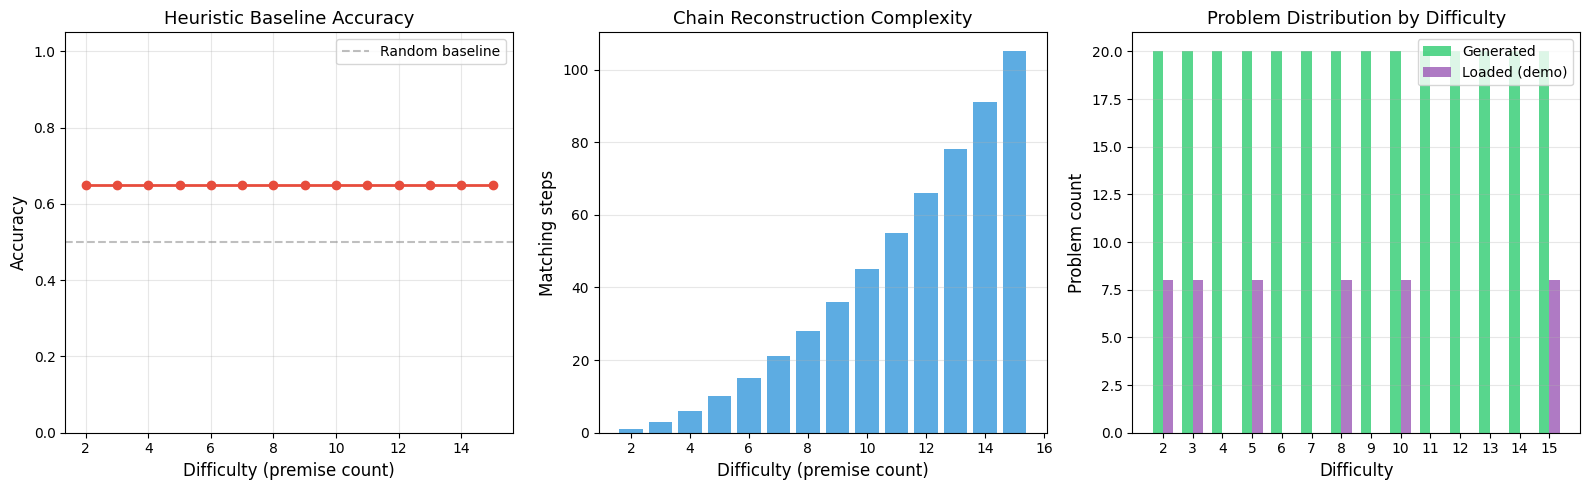


DATASET SUMMARY
Generated problems:   280
Difficulty levels:    14 (d=2-15)
Z3 verified:          280/280
Unique entity sets:   280/280
TRUE/FALSE balance:   140/140
Loaded demo examples: 48
Generation time:      1.0s


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Heuristic accuracy by difficulty
difficulties_sorted = sorted(heuristic_acc_by_level.keys())
accs = [heuristic_acc_by_level[d] for d in difficulties_sorted]
axes[0].plot(difficulties_sorted, accs, 'o-', color='#e74c3c', linewidth=2, markersize=6)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
axes[0].set_xlabel('Difficulty (premise count)', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Heuristic Baseline Accuracy', fontsize=13)
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Chain reconstruction complexity
steps = [count_chain_reconstruction_steps(d) for d in difficulties_sorted]
axes[1].bar(difficulties_sorted, steps, color='#3498db', alpha=0.8)
axes[1].set_xlabel('Difficulty (premise count)', fontsize=12)
axes[1].set_ylabel('Matching steps', fontsize=12)
axes[1].set_title('Chain Reconstruction Complexity', fontsize=13)
axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3: Distribution comparison (generated vs loaded data)
gen_diff_counts = defaultdict(int)
for p in all_problems:
    gen_diff_counts[p["metadata_difficulty"]] += 1
load_diff_counts = defaultdict(int)
for e in examples:
    load_diff_counts[e["metadata_difficulty"]] += 1

all_diffs = sorted(set(list(gen_diff_counts.keys()) + list(load_diff_counts.keys())))
x = np.arange(len(all_diffs))
width = 0.35
bars1 = axes[2].bar(x - width/2, [gen_diff_counts.get(d, 0) for d in all_diffs], width,
                     label='Generated', color='#2ecc71', alpha=0.8)
bars2 = axes[2].bar(x + width/2, [load_diff_counts.get(d, 0) for d in all_diffs], width,
                     label='Loaded (demo)', color='#9b59b6', alpha=0.8)
axes[2].set_xlabel('Difficulty', fontsize=12)
axes[2].set_ylabel('Problem count', fontsize=12)
axes[2].set_title('Problem Distribution by Difficulty', fontsize=13)
axes[2].set_xticks(x)
axes[2].set_xticklabels(all_diffs)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('demo_results.png', dpi=100, bbox_inches='tight')
plt.show()

# Summary statistics
print(f"\n{'='*60}")
print(f"DATASET SUMMARY")
print(f"{'='*60}")
print(f"Generated problems:   {len(all_problems)}")
print(f"Difficulty levels:    {len(by_difficulty)} (d={min(by_difficulty)}-{max(by_difficulty)})")
print(f"Z3 verified:          {len(all_problems)}/{total_tasks}")
print(f"Unique entity sets:   {unique_sets}/{len(all_problems)}")
print(f"TRUE/FALSE balance:   {sum(1 for p in all_problems if p['output']=='TRUE')}/{sum(1 for p in all_problems if p['output']=='FALSE')}")
print(f"Loaded demo examples: {len(examples)}")
print(f"Generation time:      {elapsed:.1f}s")